# CLASSIFICATION DES SURVIVANTS DU TITANIC

## Réalisé par :

- [Samain Florian](https://github.com/NwaSet) — 2ème année, Intar D  
- [Ducourtieux Yohann](https://github.com/Nhanyo) — 2ème année, Intar D  

## Objectif :

L’objectif de ce fichier est d’explorer notre dataset (Titanic Dataset.csv) afin d’en tirer une première compréhension. Nous chercherons également à identifier quelles variables semblent être liées à notre variable cible (`survived`).

## Table des matières

- [Réalisé par](#réalisé-par)
- [Objectif](#objectif)
- [Importation des librairies importantes pour l’analyse des données](#importation-des-librairies-importantes-pour-lanalyse-des-données)
- [Importation et nettoyage des données](#importation-et-nettoyage-des-données)
    - [Que retenir de notre première visualisation](#que-retenir-de-notre-première-visualisation)
    - [Recherche des données manquantes et type de variable pour chaque colonne](#recherche-des-données-manquantes-et-type-de-variable-pour-chaque-colonne)
    - [Vérification de la pertinence de la colonne cabin](#vérification-de-la-pertinence-de-la-colonne-cabin)
- [Exploration des données](#exploration-des-données)
    - [Première analyse](#première-analyse)
    - [L’âge a-t-il un lien avec le fait d’avoir survécu ?](#lâge-a-t-il-un-lien-avec-le-fait-davoir-survécu)
    - [Le prix payé par un passager a-t-il un lien avec la mortalité ?](#le-prix-payé-par-un-passager-a-t-il-un-lien-avec-la-mortalité)
    - [Le sexe du passager a-t-il un lien avec la mortalité ?](#le-sexe-du-passager-a-t-il-un-lien-avec-la-mortalité)
    - [La classe du passager a-t-elle un lien avec la mortalité ?](#la-classe-du-passager-a-t-elle-un-lien-avec-la-mortalité)
    - [Le deck a-t-il un lien avec la mortalité ?](#le-deck-a-t-il-un-lien-avec-la-mortalité)
    - [Les variables sibsp et parch ont-elles un lien avec la mortalité ?](#les-variables-sibsp-et-parch-ont-elles-un-lien-avec-la-mortalité)
    - [Analyse complémentaire : le port d'embarquement est-il lié à d'autres variables ?](#Analyse-complémentaire-:-le-port-d'embarquement-est-il-lié-à-d'autres-variables-?)
- [Conclusion](#Conclusion)

## Importation des librairies importantes pour l’analyse des données

Dans la cellule suivante, nous allons importer différentes librairies qui permettront l’analyse de notre dataset.

- **Pandas** : permet la manipulation des DataFrames  
- **Matplotlib** : permet de créer des visualisations graphiques des données  
- **Seaborn** : permet également la visualisation de données, avec des graphiques plus avancés  

In [ ]:
# Manipulation et gestion des données
import pandas as pd

# Visualisation des données
import matplotlib.pyplot as plt
import seaborn as sns

## Importation et nettoyage des données :

L’objectif est de créer notre DataFrame `df_titanic`, puis de vérifier le nombre de lignes et de colonnes et obtenir une première visualisation du dataset.

In [3]:
df_titanic = pd.read_csv('../data/Titanic Dataset.csv')

# vérification du nombre de variables et le nombre de données. 
print(df_titanic.shape)

# premières visualisation des données
df_titanic.head()

(1309, 11)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S


### Que retenir de notre première visualisation

**1. Nous constatons que notre base de données contient bien 1309 lignes.**

**2. Vérification des différentes informations sur les variables :**

- `pclass` : représente la classe du passager sur le navire  
- `survived` : variable cible de notre modèle  
- `name` : nom du passager  
- `sex` : sexe du passager  
- `age` : âge du passager  
- `sibsp` : nombre de frères/sœurs du passager également à bord  
- `parch` : nombre d’enfants du passager également à bord  
- `ticket` : numéro du ticket  
- `fare` : prix du ticket  
- `cabin` : numéro de la cabine où loge le passager  
- `embarked` : lieu d’embarquement du passager  

### Recherche des données manquantes et type de variable pour chaque colonne :

L’objectif est de vérifier la présence éventuelle de données manquantes, ainsi que d’identifier le type de chaque variable (numérique, catégorielle, binaire, chaîne de caractères = string).

In [4]:
# affiche une description des variable numérique
df_titanic.describe()

,pclass,survived,age,sibsp,parch,fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


In [5]:
# affiche toutes les valeurs possibles pour une variable
for col in df_titanic.columns:
        print(col)
        print(df_titanic[col].unique())
        print("--------------------------------------------------")

pclass
[1 2 3]
--------------------------------------------------
survived
[1 0]
--------------------------------------------------
name
<StringArray>
[                  'Allen, Miss. Elisabeth Walton',
                  'Allison, Master. Hudson Trevor',
                    'Allison, Miss. Helen Loraine',
            'Allison, Mr. Hudson Joshua Creighton',
 'Allison, Mrs. Hudson J C (Bessie Waldo Daniels)',
                             'Anderson, Mr. Harry',
               'Andrews, Miss. Kornelia Theodosia',
                          'Andrews, Mr. Thomas Jr',
   'Appleton, Mrs. Edward Dale (Charlotte Lamson)',
                         'Artagaveytia, Mr. Ramon',
 ...
                             'Yasbeck, Mr. Antoni',
         'Yasbeck, Mrs. Antoni (Selini Alexander)',
                            'Youseff, Mr. Gerious',
                               'Yousif, Mr. Wazli',
                           'Yousseff, Mr. Gerious',
                            'Zabour, Miss. Hileni',
            

In [6]:
# affiche les types et noms des variables
print("information sur les variables du data_frame :\n")
print(df_titanic.info())

information sur les variables du data_frame :

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   name      1309 non-null   str    
 3   sex       1309 non-null   str    
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   ticket    1309 non-null   str    
 8   fare      1308 non-null   float64
 9   cabin     295 non-null    str    
 10  embarked  1307 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 112.6 KB
None


In [7]:
# affiche le nombre de valeur null par variable
print("nombre de valeur null par class :\n\n",df_titanic.isna().sum())

nombre de valeur null par class :

 pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
dtype: int64


- `pclass`
  - 0 valeur nulle  
  - Variable catégorielle (1, 2, 3)

- `survived`
  - 0 valeur nulle  
  - Variable binaire (0 = décédé, 1 = survivant)

- `name`
  - 0 valeur nulle  
  - Chaîne de caractères

- `sex`
  - 0 valeur nulle  
  - Variable binaire (female, male)

- `age`
  - 263 valeurs nulles  
  - Variable numérique, comprise entre 0,17 et 80  

- `sibsp`
  - 0 valeur nulle  
  - Variable numérique comprise entre 0 et 8  

- `parch`
  - 0 valeur nulle  
  - Variable numérique comprise entre 0 et 9  

- `ticket`
  - 0 valeur nulle  
  - Variable catégorielle, certains tickets sont partagés entre plusieurs passagers  

- `fare`
  - 1 valeur nulle  
  - Variable numérique comprise entre 0 et 512  

- `cabin`
  - 1014 valeurs nulles  
  - Variable catégorielle  

- `embarked`
  - 2 valeurs nulles  
  - Variable catégorielle (C = Cherbourg, Q = Queenstown, S = Southampton)

Nous constatons qu’un grand nombre de valeurs est manquant pour la variable `cabin`. Nous allons donc évaluer si cette colonne reste pertinente pour notre modèle.

Avant cela, nous allons remplacer les valeurs nulles des colonnes `age` et `fare` par leur moyenne, puis supprimer les lignes contenant des valeurs nulles dans la colonne `embarked`.

In [8]:
df_titanic_clean = df_titanic.dropna(subset=["embarked"])
df_titanic_clean["fare"] = df_titanic_clean["fare"].fillna(df_titanic_clean["fare"].mean())
df_titanic_clean["age"] = df_titanic_clean["age"].fillna(
    df_titanic_clean.groupby(["pclass", "sex"])["age"].transform("mean")
)
# par sex ?
# vérifié .

# vérification :
print("nombre de valeur null par class :\n\n",df_titanic_clean.isna().sum())
df_titanic_clean.describe()

nombre de valeur null par class :

 pclass         0
survived       0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
cabin       1014
embarked       0
dtype: int64


,pclass,survived,age,sibsp,parch,fare
count,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000
mean,2.296863,0.381025,29.342962,0.499617,0.385616,33.223956
std,0.836942,0.485825,13.144974,1.042273,0.866092,51.746164
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,22.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,26.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,36.500000,1.000000,0.000000,31.275000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


Nous constatons que la modification des valeurs nulles n’a pas eu d’impact significatif sur nos colonnes et qu’il ne reste plus de données manquantes dans notre DataFrame, à l’exception de la colonne `cabin`.

Un nouveau DataFrame a été créé, dans lequel les valeurs nulles ont été traitées (à l’exception de la colonne `cabin`).

### Vérification de la pertinence de la colonne cabin :

L’objectif est de déterminer si la colonne `cabin` est utile dans notre DataFrame ou s’il existe une corrélation avec une autre variable.

Dans un premier temps, nous allons vérifier si le prix payé par le passager est lié à la cabine ainsi qu’à sa survie.

Nous allons uniquement conserver la lettre de la cabine, que nous stockerons dans une nouvelle variable du DataFrame appelée `deck` (correspondant au pont où se situe la cabine).

Ensuite, nous réaliserons deux graphiques :
- un montrant la relation entre le `deck` et le nombre de survivants  
- un autre présentant la moyenne du prix payé par les passagers  

Si les deux graphiques présentent des tendances similaires, cela suggérera l’existence d’un lien entre les variables `fare` et `cabin`.

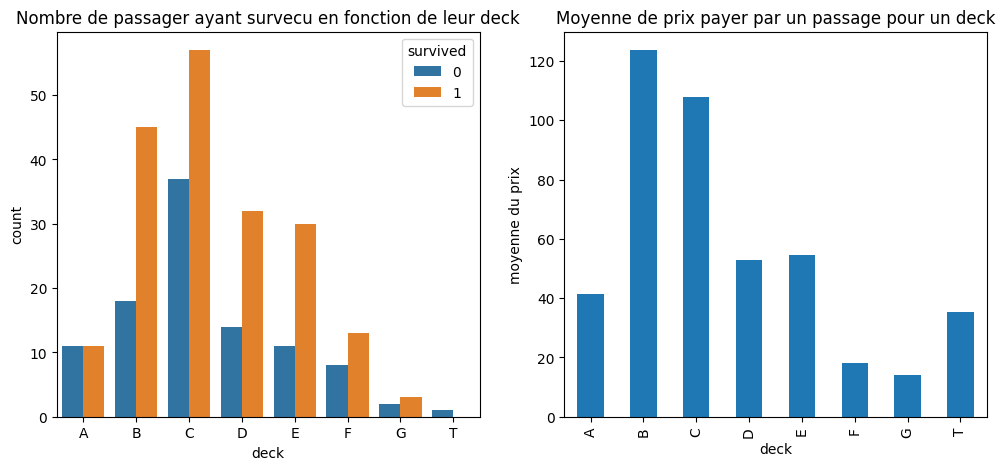

nombre de ligne pour le deck T : 1


In [9]:
df_titanic_clean["deck"] = df_titanic_clean["cabin"].str[0]

########## plot 1 ##########

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
sns.countplot(x="deck", hue="survived", data=df_titanic_clean,order=sorted(df_titanic_clean["deck"].dropna().unique()), ax=axes[0])

########## plot 2 ##########
means = df_titanic_clean.groupby("deck")["fare"].mean()
means.plot(kind="bar", ax=axes[1], ylabel="moyenne du prix")

axes[0].set_title("Nombre de passager ayant survecu en fonction de leur deck")
axes[1].set_title("Moyenne de prix payer par un passage pour un deck")

plt.show()

# modification apportée !
print(f"nombre de ligne pour le deck T : {len(df_titanic_clean.loc[df_titanic_clean["deck"] == "T"])}")

# faire ne pourcentage

Nous constatons que les deux variables sont liées : il existe probablement une relation entre le prix payé par un passager et le pont (`deck`) sur lequel il a séjourné.

Nous allons donc supprimer la colonne `cabin`, car elle est redondante avec la variable `fare`.

**modification apportée :**

Nous avons constaté qu’il n’existait qu’une seule ligne associée au deck `T`. Nous avons donc supposé qu’il s’agissait d’une donnée aberrante.
Après avoir effectué des recherches, nous avons confirmé qu’aucun deck du Titanic ne correspond à la valeur `T`. Il s’agit donc bien d’une anomalie dans les données, ce qui nous a conduits à décider de supprimer cette ligne.

In [10]:
df_titanic_clean = df_titanic_clean.drop(columns=["cabin"])
df_titanic_clean = df_titanic_clean[df_titanic_clean['deck'] != 'T']

## Exploration des données :

Dans un premier temps, nous allons réaliser des histogrammes afin de visualiser la distribution de chaque variable et identifier celles qui semblent pertinentes.

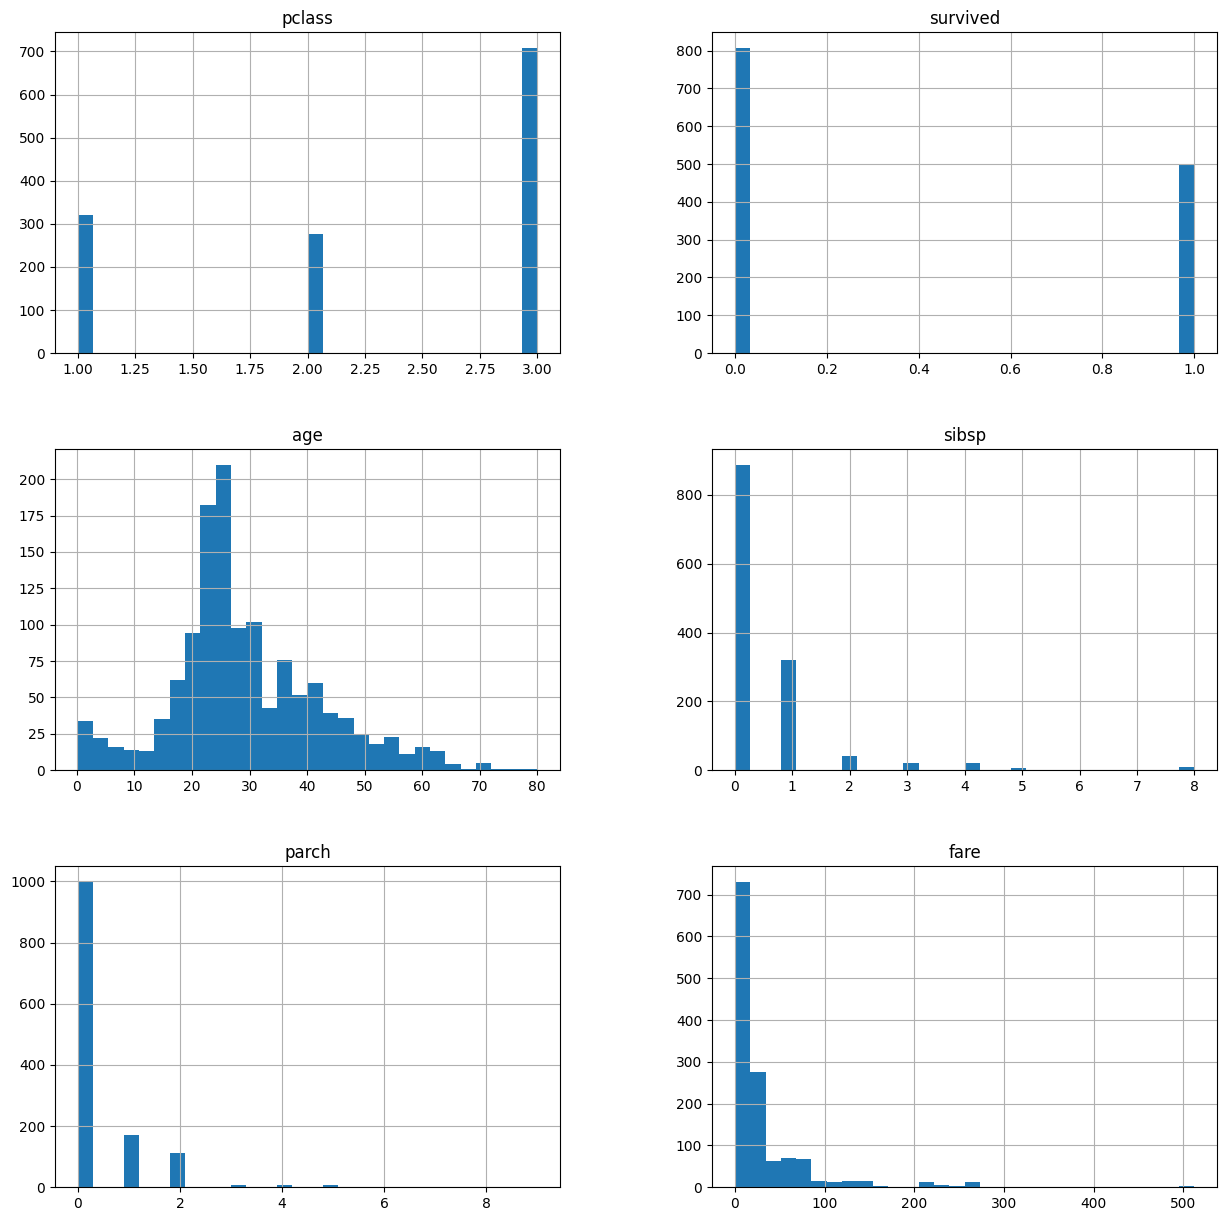

In [11]:
df_titanic_clean.hist(bins=30, figsize=(15,15))
plt.show()

### Première analyse :

Tout d’abord, nous constatons qu’un grand nombre de passagers ont un âge d’environ 25 ans, ce qui est cohérent. Nous avons précédemment choisi de remplacer les valeurs nulles par la moyenne de leur afin de ne pas perdre près de 250 lignes de données.

Nous observons également que les variables `sibsp` et `parch` sont des variables discrètes.

Enfin, concernant la variable `fare`, une valeur semble nettement plus élevée que les autres, ce qui pourrait correspondre à une donnée aberrante. Nous allons donc la supprimer afin de ne pas biaiser les analyses futures.

In [12]:
df_titanic_clean = df_titanic_clean[df_titanic_clean["fare"] <= 400]

### L’âge a-t-il un lien avec le fait d’avoir survécu ?

Notre objectif est de vérifier s’il existe une relation entre l’âge et la survie du passager. Pour cela, nous allons réaliser deux boxplots afin d’observer s’il existe une différence d’âge entre les passagers décédés et les survivants.

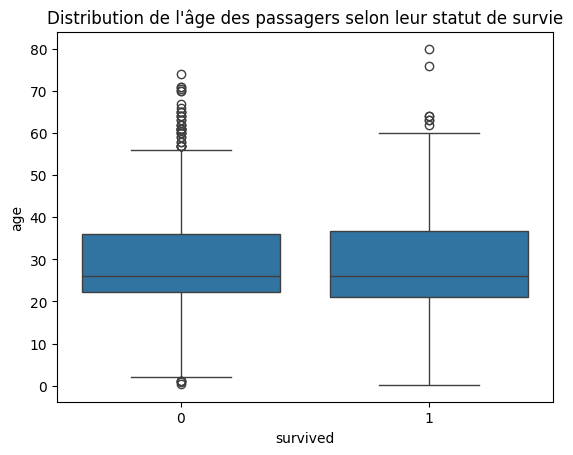

In [13]:
df_titanic_target = df_titanic_clean["survived"]
sns.boxplot(x=df_titanic_target, y=df_titanic_clean["age"])
plt.title("Distribution de l'âge des passagers selon leur statut de survie")
plt.show()

L’âge ne semble pas avoir d’impact significatif sur les boxplots. On observe simplement que la moustache inférieure pour les survivants descend plus bas, ce qui signifie que le premier quartile est plus faible (Q1 - 1,5 × écart interquartile).

Nous allons maintenant réaliser un ***swarmplot***, qui permet de visualiser chaque donnée individuellement. Cela nous permettra de vérifier plus facilement si le nombre de jeunes survivants est supérieur au nombre de jeunes passagers décédés.

c:\Users\samai\Desktop\Cours\Q2\Machine Learning\ML-Titanic\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\samai\Desktop\Cours\Q2\Machine Learning\ML-Titanic\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 37.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\samai\Desktop\Cours\Q2\Machine Learning\ML-Titanic\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


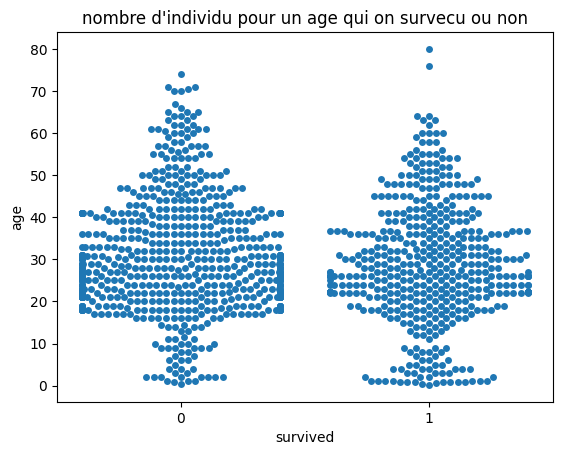

In [14]:
sns.swarmplot(x=df_titanic_target, y=df_titanic_clean["age"])
plt.title("nombre d'individu pour un age qui on survecu ou non")
plt.show()

Nous constatons qu’à partir d’environ 20 ans, les points se superposent fortement, ce qui limite la lisibilité du graphique. Toutefois, ce n’est pas l’élément le plus important.

On observe que le nombre de passagers ayant survécu et âgés de moins de 10 ans est supérieur à celui des passagers du même âge n’ayant pas survécu.

Nous pouvons donc en conclure que le jeune âge semble être associé à une probabilité de survie plus élevée.

### Le prix payé par un passager a-t-il un lien avec la mortalité ?

L’objectif est de déterminer si le fait qu’un passager ait payé sa place plus cher influence ses chances de survie. Pour cela, nous allons réaliser un boxplot afin d’observer si, chez les survivants, les valeurs sont globalement plus élevées ou plus faibles.

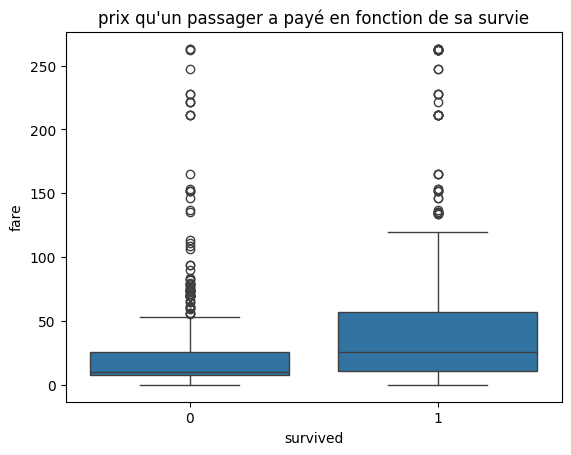

In [15]:
sns.boxplot(x=df_titanic_target, y=df_titanic_clean["fare"])
plt.title("prix qu'un passager a payé en fonction de sa survie")
plt.show()

Sur la base de ce boxplot, nous constatons que les 50 % des valeurs centrales (médiane) pour les survivants sont significativement plus élevées que celles des passagers décédés.  

Cela suggère que les passagers ayant payé leur place plus cher avaient une probabilité de survie plus élevée.

### Le sexe du passager a-t-il un lien avec la mortalité ?

Notre objectif est de déterminer s’il existe une relation entre le sexe du passager et la mortalité. Pour cela, nous utiliserons un ***countplot***, qui est particulièrement adapté pour compter le nombre d’individus au sein d’une variable catégorielle.

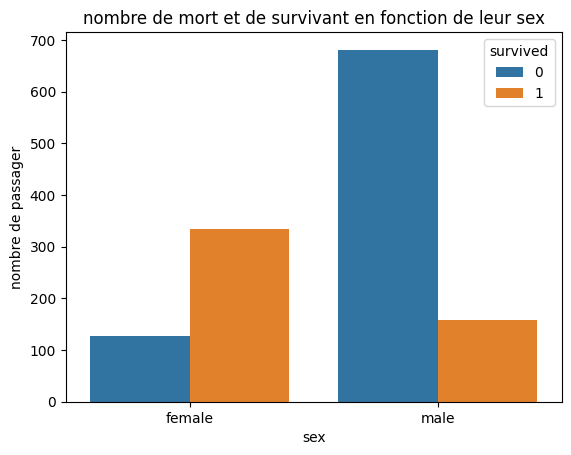

In [16]:
sns.countplot(x="sex", hue="survived", data=df_titanic_clean)
plt.title("nombre de mort et de survivant en fonction de leur sex")
plt.ylabel("nombre de passager")
plt.show()

Nous constatons immédiatement que les femmes ont une probabilité de survie nettement plus élevée, tandis que les hommes présentent une probabilité plus importante de ne pas survivre au naufrage.

### La classe du passager a-t-elle un lien avec la mortalité ?

Notre objectif est de déterminer si le fait qu’un passager appartienne à une classe plus élevée augmente ses chances de survie. Nous pouvons déjà supposer que cela aura un impact, étant donné que le prix du billet semble influencer la probabilité de survie.

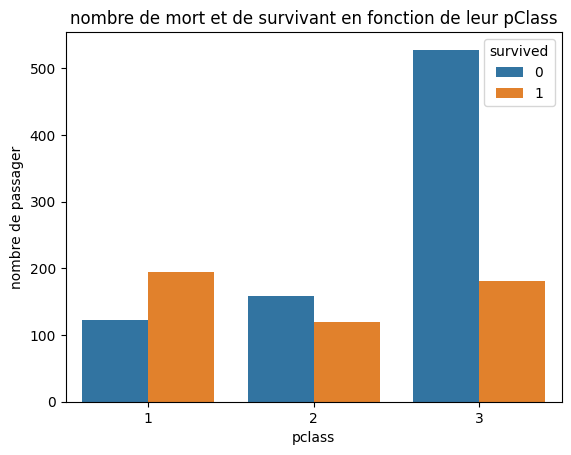

In [17]:
sns.countplot(x="pclass", hue="survived", data=df_titanic_clean)
plt.title("nombre de mort et de survivant en fonction de leur pClass")
plt.ylabel("nombre de passager")
plt.show()

Comme prévu, nous constatons que les passagers de première classe ont une probabilité de survie plus élevée que ceux de troisième classe.

**Ajout :**

nous alons maintenant verifier si il existe un lien entre le prix et le pclass du passager. l'objectif serait de voir si les gens on bien payer plus chère pour être en première et deuxième class plutôt qu'en troisième.

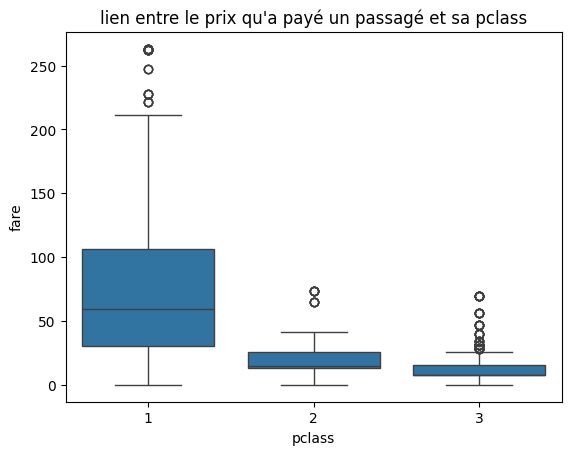

In [18]:
sns.boxplot(
    data=df_titanic_clean,
    x="pclass",
    y="fare",
)
plt.title("lien entre le prix qu'a payé un passagé et sa pclass")
plt.show()

Nous constatons que le prix payé par les passagers est bien lié à leur classe. En effet, les tarifs de la première classe sont globalement plus élevés que ceux des deux autres classes.

### Le deck a-t-il un lien avec la mortalité ?

L’objectif est de déterminer, à l’aide d’un ***countplot***, s’il existe une relation entre le `deck` et le `nombre de survivants`.

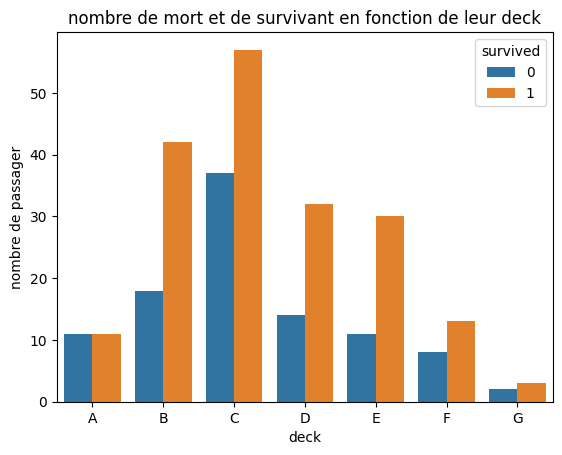

In [19]:
sns.countplot(x="deck", hue="survived", data=df_titanic_clean,order=sorted(df_titanic_clean["deck"].dropna().unique()))
plt.title("nombre de mort et de survivant en fonction de leur deck")
plt.ylabel("nombre de passager")
plt.show()

Nous observons qu’il existe effectivement une relation entre le `deck` et la probabilité de survie. Les passagers situés sur les decks **B, C, D et E** semblent avoir de meilleures chances de survivre que les autres.

**Ajout :**

Nous souhaitons désormais vérifier s’il existe également un lien entre le deck du passager et le prix payé, afin de renforcer l’hypothèse selon laquelle le prix du billet influence la survie.

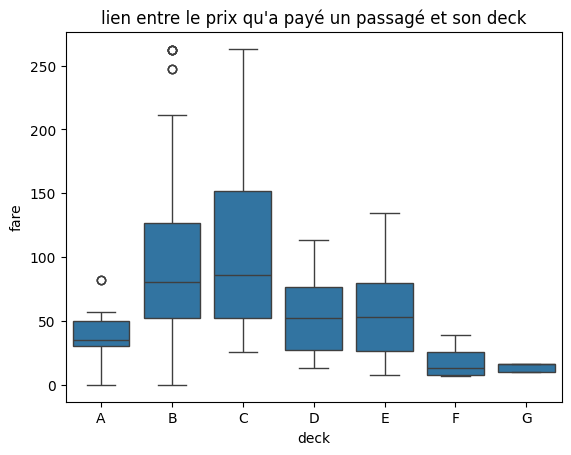

In [20]:
sns.boxplot(
    data=df_titanic_clean,
    x="deck",
    y="fare",
    order=sorted(df_titanic_clean["deck"].dropna().unique())
)
plt.title("lien entre le prix qu'a payé un passagé et son deck")
plt.show()

Une nouvelle fois, le boxplot montre que les valeurs associées aux decks **B, C, D et E** sont globalement plus élevées que celles des autres. Cela indique que les passagers présents sur ces decks ont payé leur place plus cher.

**Ajout :**

Nous allons maintenant chercher à déterminer s’il existe une relation entre le deck et la variable `pclass`. Cela pourrait permettre d’expliquer pourquoi de nombreuses données concernant les cabines des passagers sont manquantes.

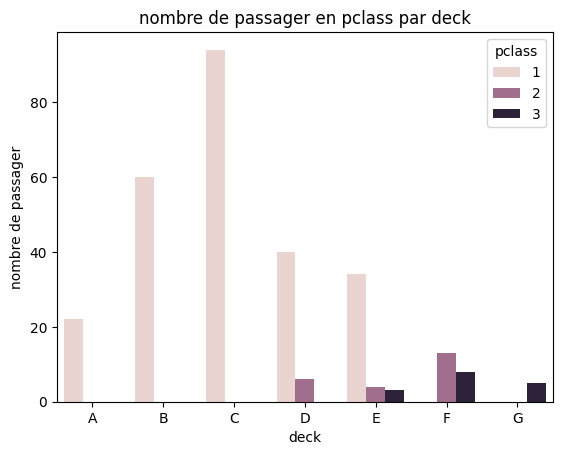

In [21]:
sns.countplot(x="deck",
              hue="pclass",
              data=df_titanic_clean,
              order=sorted(df_titanic_clean["deck"].dropna().unique()) )

plt.title("nombre de passager en pclass par deck")
plt.ylabel("nombre de passager")
plt.show()

Nous constatons que les classes 2 et 3 sont les moins représentées en termes de données de cabine. Après avoir effectué des recherches, nous avons compris que cela s’explique par la manière dont la compagnie enregistrait les cabines des passagers. En effet, les passagers de 2e et 3e classe ne disposaient pas toujours d’une cabine précisément attribuée, ce qui explique la présence de nombreuses valeurs manquantes.

De plus, cette observation confirme une nouvelle fois que le prix payé par les passagers est lié à la fois au deck et à la classe (`pclass`).

### Les variables sibsp et parch ont-elles un lien avec la mortalité ?

L’objectif est de déterminer si le nombre de frères/sœurs (**sibsp**) ou de parents/enfants (**parch**) à bord influence la probabilité de survie du passager.

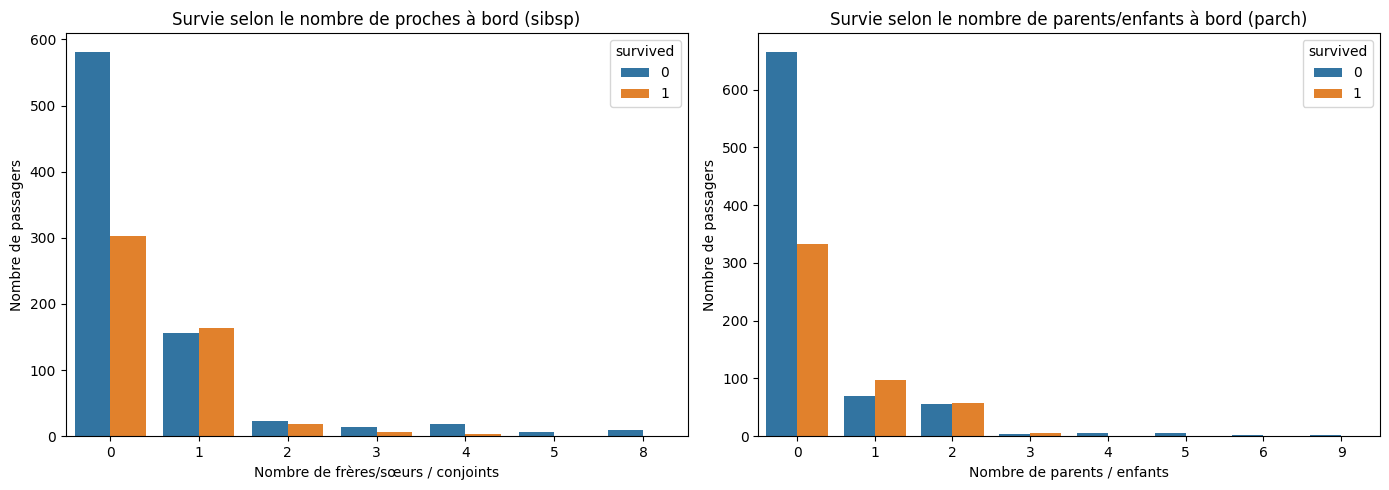

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sibsp
sns.countplot(data=df_titanic_clean, x="sibsp", hue="survived", ax=axes[0])
axes[0].set_title("Survie selon le nombre de proches à bord (sibsp)")
axes[0].set_xlabel("Nombre de frères/sœurs / conjoints")
axes[0].set_ylabel("Nombre de passagers")

# parch
sns.countplot(data=df_titanic_clean, x="parch", hue="survived", ax=axes[1])
axes[1].set_title("Survie selon le nombre de parents/enfants à bord (parch)")
axes[1].set_xlabel("Nombre de parents / enfants")
axes[1].set_ylabel("Nombre de passagers")

plt.tight_layout()
plt.show()

Nous constatons que lorsqu’un passager voyage seul, environ la moitié ne survit pas. Pour les autres cas, la répartition tend vers un équilibre proche de 50/50.

De plus, il semble que plus un passager a de liens familiaux avec d’autres personnes à bord, plus la proportion de survivants augmente par rapport au nombre de passagers décédés.

### Analyse complémentaire : le port d'embarquement est-il lié à d'autres variables ?

L’objectif de cette analyse est d’identifier d’éventuelles relations entre la variable `embarked` (port d’embarquement) et d’autres variables du dataset.

Nous cherchons à déterminer si le port d’embarquement est associé à certaines caractéristiques des passagers, telles que la classe (`pclass`), le prix du billet (`fare`) ou encore la survie (`survived`), afin d’évaluer sa pertinence dans la construction du modèle prédictif.

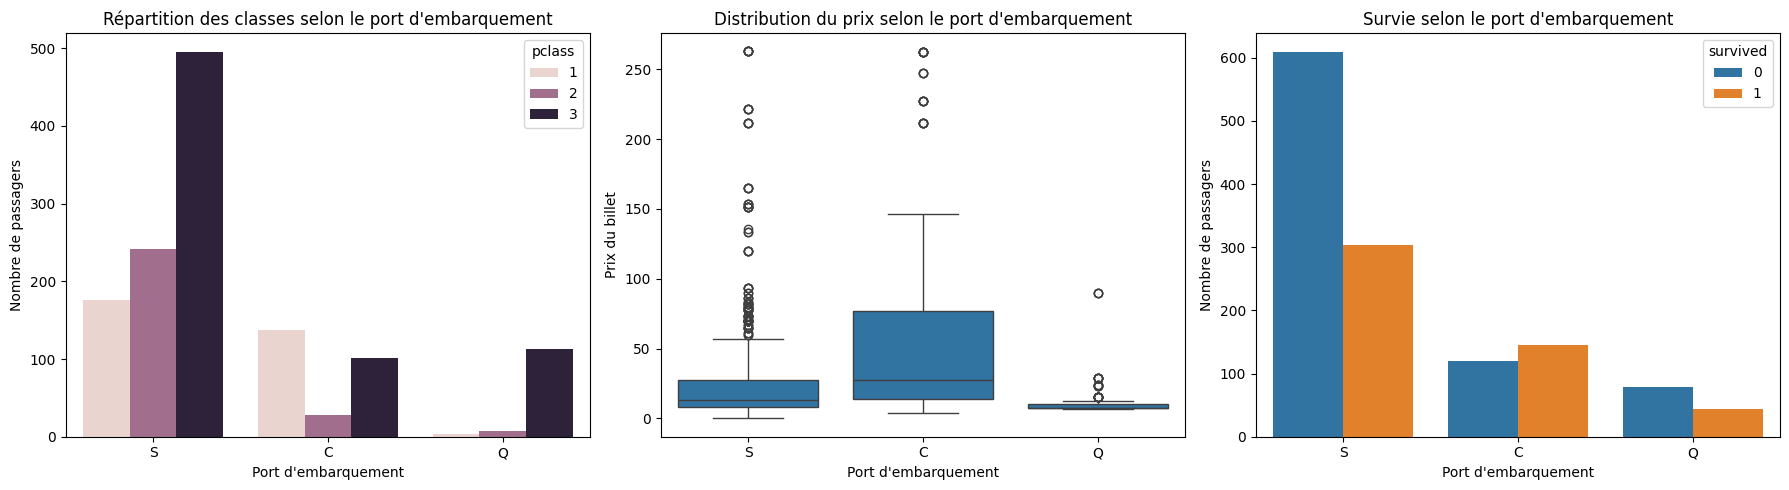

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=df_titanic_clean,
    x="embarked",
    hue="pclass",
    ax=axes[0]
)
axes[0].set_title("Répartition des classes selon le port d'embarquement")
axes[0].set_xlabel("Port d'embarquement")
axes[0].set_ylabel("Nombre de passagers")

sns.boxplot(
    data=df_titanic_clean,
    x="embarked",
    y="fare",
    ax=axes[1]
)
axes[1].set_title("Distribution du prix selon le port d'embarquement")
axes[1].set_xlabel("Port d'embarquement")
axes[1].set_ylabel("Prix du billet")

sns.countplot(
    data=df_titanic_clean,
    x="embarked",
    hue="survived",
    ax=axes[2]
)
axes[2].set_title("Survie selon le port d'embarquement")
axes[2].set_xlabel("Port d'embarquement")
axes[2].set_ylabel("Nombre de passagers")

plt.tight_layout()
plt.show()

C = Cherbourg, Q = Queenstown, S = Southampton

Dans un premier temps, la répartition des passagers selon les ports d’embarquement semble relativement équilibrée, ce qui pourrait laisser penser qu’il n’existe pas de lien particulier entre cette variable et les autres.

Cependant, une analyse plus approfondie révèle des différences notables. Le port de Cherbourg se distingue par une proportion plus élevée de passagers en première classe (`pclass`). Par conséquent, le prix des billets (`fare`) y est également plus élevé en moyenne.

De plus, on observe que les passagers embarqués à Cherbourg présentent un taux de survie plus important que de décès. Cette tendance s’explique probablement par leur appartenance majoritaire à des classes sociales plus élevées, historiquement favorisées lors de l’évacuation.

Ainsi, le port d’embarquement apparaît comme une variable pertinente, car il est indirectement lié à d’autres facteurs influents tels que la classe et le prix du billet. Il peut donc être considéré comme utile dans le cadre de la modélisation prédictive.

## Conclusion

Cette analyse descriptive du dataset Titanic nous a permis de mettre en évidence plusieurs relations significatives entre les variables et la survie des passagers.

Tout d’abord, certaines variables démographiques présentent un impact notable. Le sexe apparaît comme un facteur déterminant, avec une probabilité de survie nettement plus élevée chez les femmes. L’âge, quant à lui, montre une tendance plus modérée, bien que les jeunes passagers semblent légèrement favorisés en termes de survie.

Ensuite, les variables socio-économiques jouent un rôle central. Le prix du billet (`fare`) est fortement corrélé à la survie : les passagers ayant payé plus cher présentent une probabilité plus élevée de survivre. Cette observation est cohérente avec l’influence de la classe (`pclass`), où les passagers de première classe sont avantagés par rapport à ceux de troisième classe.

L’analyse du `deck` renforce cette hypothèse. Les passagers situés sur certains ponts (notamment B, C, D et E) présentent de meilleures chances de survie, ce qui est également associé à des prix de billets plus élevés. Cela confirme l’existence d’un lien indirect entre la position dans le navire, le statut socio-économique et la survie.
De plus, nous avons montrer que les `deck` avec un plus grand nombre de survivant sont ceux avec plus de premère class renforcant encore plus le lien entre le `deck`, `pclass`, `fare` et `survived`.

l’analyse des variables `sibsp` et `parch` met en évidence une influence du contexte familial sur la survie. Les passagers voyageant seuls présentent une probabilité de survie plus faible, tandis que ceux accompagnés de proches semblent bénéficier de meilleures chances de survie. Cette tendance suggère que la présence de liens familiaux à bord a pu jouer un rôle favorable lors du naufrage.

La variable `embarked` apparaît également comme importante, car elle met en évidence que le rapport entre le nombre de survivants et le nombre de décès peut être influencé par le port d’embarquement.

Enfin, le nettoyage des données a permis de traiter efficacement les valeurs manquantes tout en conservant la majorité des informations pertinentes, garantissant ainsi la fiabilité de l’analyse.

En conclusion, cette étude met en évidence que la survie des passagers du Titanic dépend principalement de facteurs liés au statut social (classe, prix, emplacement) ainsi que de caractéristiques individuelles comme le sexe, ouvrant la voie à de futures analyses prédictives.

Pour la suite, nous réaliserons une phase de prétraitement des données (*preprocessing*) avant de construire notre modèle prédictif.L’objectif sera de préparer le dataset afin d’exploiter au mieux les données disponibles et d’optimiser les performances du modèle.